# Symbolic Analysis of a Four-Bar Coupler Curve

Unlike numerical simulation, symbolic computation gives **closed-form algebraic
expressions** for joint trajectories. This is unique to pylinkage and enables:

- Exact coupler curve equations (algebraic curves, not sampled points)
- Theta elimination to get implicit f(x,y) = 0 equations
- Parametric optimization with analytical gradients
- Mathematical insight into linkage behavior

**What you'll learn:**
- Creating a symbolic four-bar linkage
- Extracting trajectory expressions as SymPy formulas
- Eliminating theta to get the coupler curve equation
- Computing numeric trajectories from symbolic expressions
- Gradient-based optimization with `SymbolicOptimizer`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

from pylinkage.symbolic import (
    SymbolicOptimizer,
    compute_trajectory_numeric,
    eliminate_theta,
    fourbar_symbolic,
    solve_linkage_symbolically,
    theta,
)

## 1. Create a Symbolic Four-Bar

Link lengths can be numeric or symbolic parameters. Using string names creates
SymPy symbols that appear in the trajectory expressions.

In [2]:
# Create four-bar with symbolic coupler and rocker lengths
linkage = fourbar_symbolic(
    ground_length=4,      # d = 4 (fixed)
    crank_length=1,       # a = 1 (fixed)
    coupler_length="L2",  # b = symbolic
    rocker_length="L3",   # c = symbolic
)

print(f"Linkage: {linkage}")
print(f"Joints: {[j.name for j in linkage.joints]}")
print(f"Parameters: {linkage.parameters}")
print(f"Input angle: {linkage.theta}")

Linkage: SymbolicLinkage(name='fourbar', joints=['A', 'D', 'B', 'C'])
Joints: ['A', 'D', 'B', 'C']
Parameters: {'L3': L3, 'L2': L2}
Input angle: theta


## 2. Solve for Trajectory Expressions

The solver returns closed-form (x(theta), y(theta)) expressions for each joint.

In [3]:
trajectories = solve_linkage_symbolically(linkage)

for name, (x_expr, y_expr) in trajectories.items():
    print(f"\n--- Joint {name} ---")
    print(f"x({theta}) = {x_expr}")
    print(f"y({theta}) = {y_expr}")


--- Joint A ---
x(theta) = 0.0
y(theta) = 0.0

--- Joint D ---
x(theta) = 4.00000000000000
y(theta) = 0.0

--- Joint B ---
x(theta) = cos(theta)
y(theta) = sin(theta)

--- Joint C ---
x(theta) = (sqrt((4*L2**2*(17.0 - 8.0*cos(theta)) - (1.0*L2**2 - 1.0*L3**2 - 8.0*cos(theta) + 17.0)**2)/(17.0 - 8.0*cos(theta)))*(17.0 - 8.0*cos(theta))*sin(theta) + 2*(17.0 - 8.0*cos(theta))**(3/2)*cos(theta) - sqrt(17.0 - 8.0*cos(theta))*(cos(theta) - 4.0)*(1.0*L2**2 - 1.0*L3**2 - 8.0*cos(theta) + 17.0))/(2*(17.0 - 8.0*cos(theta))**(3/2))
y(theta) = (-sqrt((4*L2**2*(17.0 - 8.0*cos(theta)) - (1.0*L2**2 - 1.0*L3**2 - 8.0*cos(theta) + 17.0)**2)/(17.0 - 8.0*cos(theta)))*(17.0 - 8.0*cos(theta))*(cos(theta) - 4.0) + 2*(17.0 - 8.0*cos(theta))**(3/2)*sin(theta) - sqrt(17.0 - 8.0*cos(theta))*(1.0*L2**2 - 1.0*L3**2 - 8.0*cos(theta) + 17.0)*sin(theta))/(2*(17.0 - 8.0*cos(theta))**(3/2))


In [4]:
# Get the coupler point C expressions
x_C, y_C = trajectories["C"]

# Pretty-print
print("Coupler point trajectory:")
sp.pprint(sp.Eq(sp.Symbol('x_C'), x_C))
print()
sp.pprint(sp.Eq(sp.Symbol('y_C'), y_C))

Coupler point trajectory:
            __________________________________________________________________ ↪
           ╱                                                                   ↪
          ╱      2                       ⎛      2         2                    ↪
         ╱   4⋅L₂ ⋅(17.0 - 8.0⋅cos(θ)) - ⎝1.0⋅L₂  - 1.0⋅L₃  - 8.0⋅cos(θ) + 17. ↪
        ╱    ───────────────────────────────────────────────────────────────── ↪
      ╲╱                              17.0 - 8.0⋅cos(θ)                        ↪
x_C = ──────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪ ____                                                                         ↪
↪   2                                                                          ↪
↪  ⎞                                                                           ↪
↪

## 3. Compute Numeric Trajectories

Substitute specific parameter values to get numeric (x, y) positions.

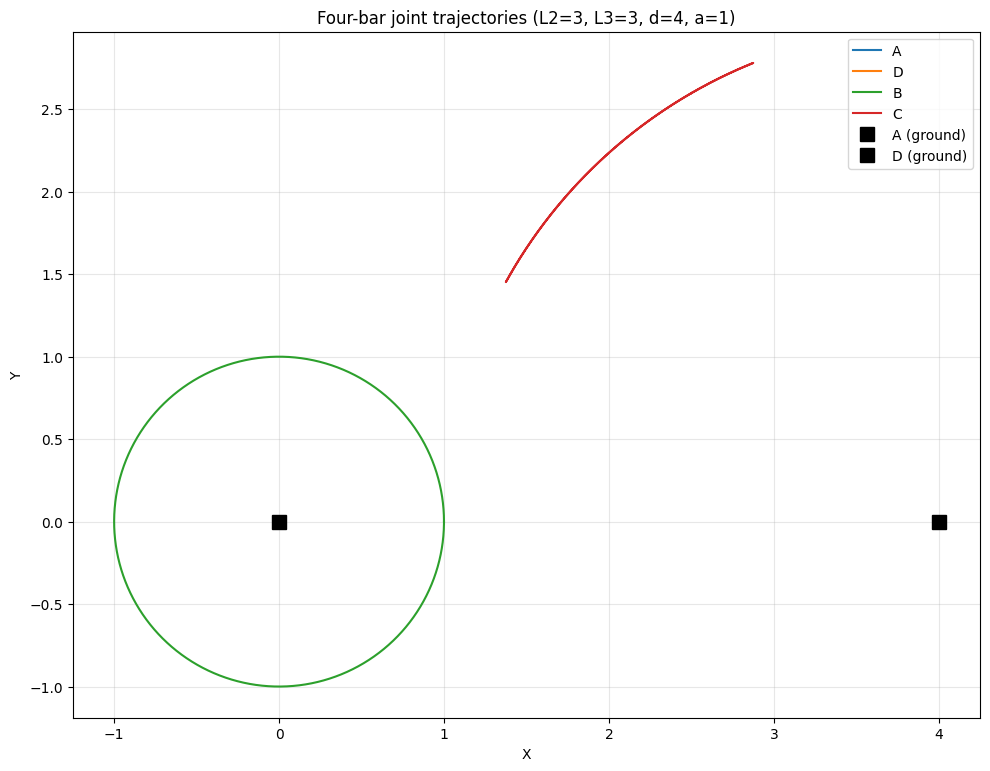

In [5]:
# Parameter values: classic crank-rocker
params = {"L2": 3.0, "L3": 3.0}
theta_values = np.linspace(0, 2 * np.pi, 500)

trajectories_num = compute_trajectory_numeric(linkage, params, theta_values)

# Plot all joint trajectories
fig, ax = plt.subplots(figsize=(10, 8))

for name, positions in trajectories_num.items():
    # Filter NaN (unbuildable positions)
    valid = ~np.isnan(positions[:, 0])
    ax.plot(positions[valid, 0], positions[valid, 1], linewidth=1.5, label=name)

# Mark ground pivots
ax.plot(0, 0, 'ks', markersize=10, label='A (ground)')
ax.plot(4, 0, 'ks', markersize=10, label='D (ground)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Four-bar joint trajectories (L2=3, L3=3, d=4, a=1)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Eliminate Theta: Implicit Coupler Curve Equation

The parametric equations x(theta), y(theta) can be converted to an implicit
algebraic equation f(x, y) = 0. This is the **coupler curve equation** —
a classical result in mechanism theory.

For a four-bar, the coupler curve is generally a **sextic** (degree 6) algebraic curve.

In [6]:
# Use a fully numeric four-bar for theta elimination
# (symbolic parameters make Groebner basis computation very slow)
linkage_numeric = fourbar_symbolic(
    ground_length=4,
    crank_length=1,
    coupler_length=3,
    rocker_length=3,
)

traj_num = solve_linkage_symbolically(linkage_numeric)
x_C_num, y_C_num = traj_num["C"]

print("Attempting theta elimination (this may take a moment)...")
implicit_eq = eliminate_theta(x_C_num, y_C_num)

if implicit_eq is not None:
    x, y = sp.symbols('x y')
    print("\nImplicit coupler curve equation f(x,y) = 0:")
    print(f"Degree: {sp.degree(implicit_eq, x) + sp.degree(implicit_eq, y)}")
    sp.pprint(sp.Eq(implicit_eq, 0))
else:
    print("Theta elimination did not converge (try simpler parameters).")

Attempting theta elimination (this may take a moment)...

Implicit coupler curve equation f(x,y) = 0:
Degree: 0
                  _______________________                                      ↪
                 ╱        ⎛    π⎞                      ⎛    π⎞                 ↪
        1.0⋅y⋅  ╱  8.0⋅sin⎜θ + ─⎟ + 19.0       14.0⋅sin⎜θ + ─⎟                 ↪
              ╲╱          ⎝    2⎠                      ⎝    2⎠               4 ↪
1.0⋅x - ───────────────────────────────── - ───────────────────── - ────────── ↪
               _______________________             ⎛    π⎞                 ⎛   ↪
              ╱               ⎛    π⎞       8.0⋅sin⎜θ + ─⎟ - 17.0   8.0⋅sin⎜θ  ↪
             ╱  17.0 - 8.0⋅sin⎜θ + ─⎟              ⎝    2⎠                 ⎝   ↪
           ╲╱                 ⎝    2⎠                                          ↪

↪                
↪                
↪                
↪ .0             
↪ ─────────── = 0
↪   π⎞           
↪ + ─⎟ - 17.0    
↪   2⎠           
↪             

## 5. Explore the Parameter Space

Vary the coupler length to see how the coupler curve changes shape.

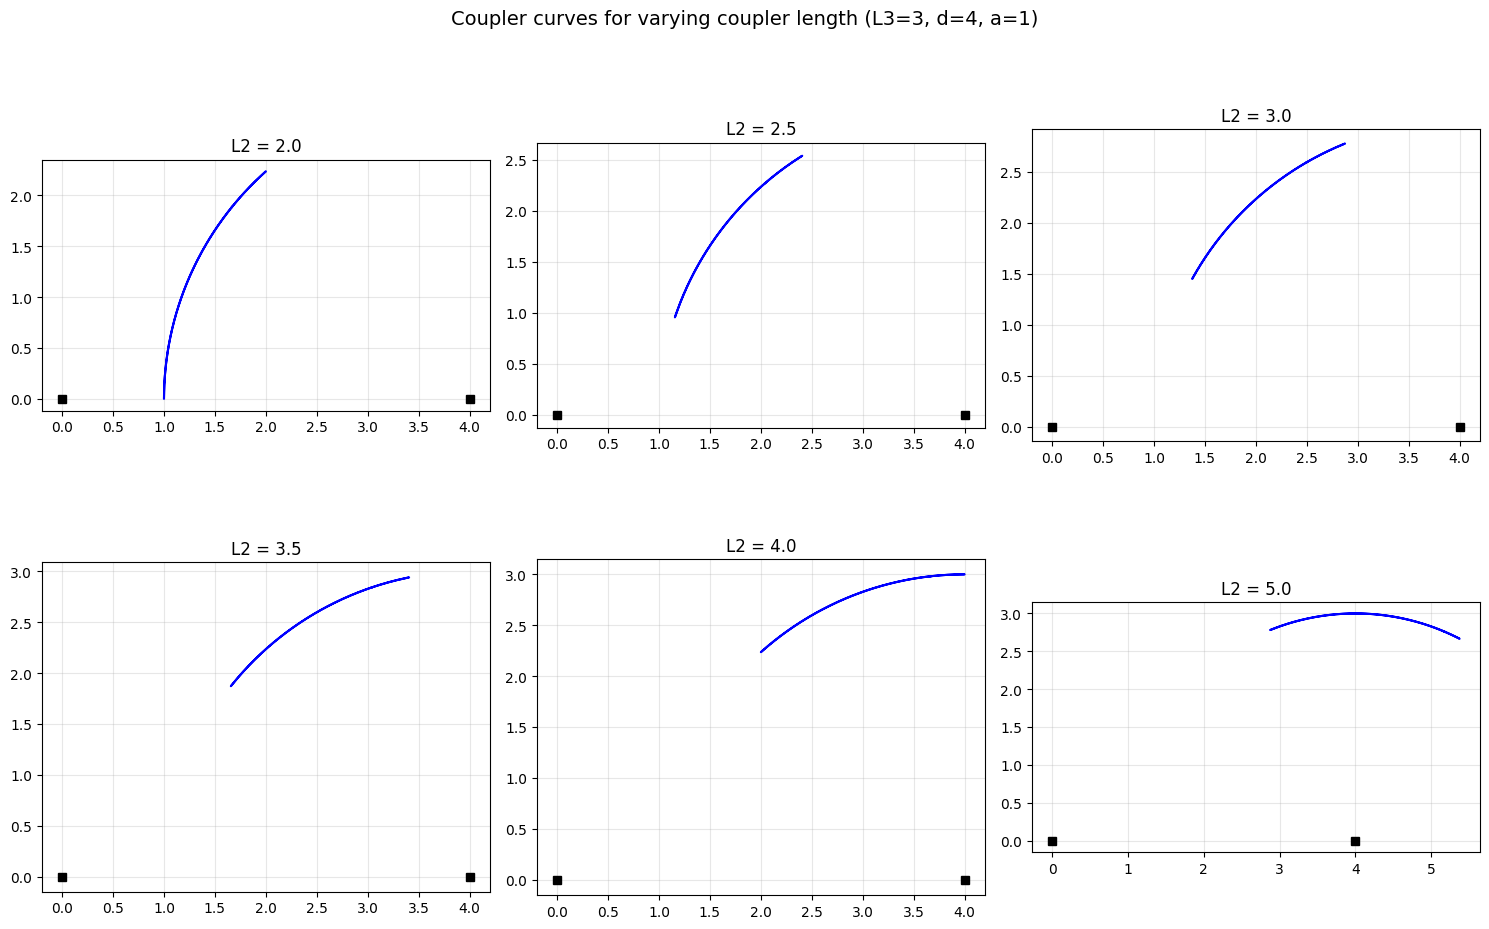

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

L2_values = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]

for ax, L2_val in zip(axes.flat, L2_values, strict=False):
    try:
        traj = compute_trajectory_numeric(
            linkage,
            {"L2": L2_val, "L3": 3.0},
            theta_values,
        )
        C_pos = traj["C"]
        valid = ~np.isnan(C_pos[:, 0])
        ax.plot(C_pos[valid, 0], C_pos[valid, 1], 'b-', linewidth=1.5)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', transform=ax.transAxes, ha='center')

    ax.plot(0, 0, 'ks', markersize=6)
    ax.plot(4, 0, 'ks', markersize=6)
    ax.set_title(f'L2 = {L2_val}', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('Coupler curves for varying coupler length (L3=3, d=4, a=1)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Symbolic Optimization

Optimize link lengths to make the coupler curve pass close to a target point.
The `SymbolicOptimizer` computes analytical gradients from the symbolic expressions
and uses scipy's gradient-based solvers.

In [8]:
# Objective: minimize the distance from coupler point C to target (2, 3)
# at crank angle theta = pi/2

def objective(trajectories):
    """Symbolic objective: distance from C to (2, 3) at theta = pi/2."""
    x, y = trajectories["C"]
    target_x, target_y = 2.0, 3.0
    return (x - target_x)**2 + (y - target_y)**2

optimizer = SymbolicOptimizer(linkage, objective, theta_samples=20)

result = optimizer.optimize(
    initial_params={"L2": 3.0, "L3": 3.0},
    bounds={"L2": (1.5, 6.0), "L3": (1.5, 6.0)},
)

print(f"Optimization success: {result.success}")
print(f"Optimal parameters: {result.params}")
print(f"Objective value: {result.objective_value:.6f}")

Optimization success: True
Optimal parameters: {'L2': np.float64(3.5974701346562448), 'L3': np.float64(3.6319419105471633)}
Objective value: 0.580132


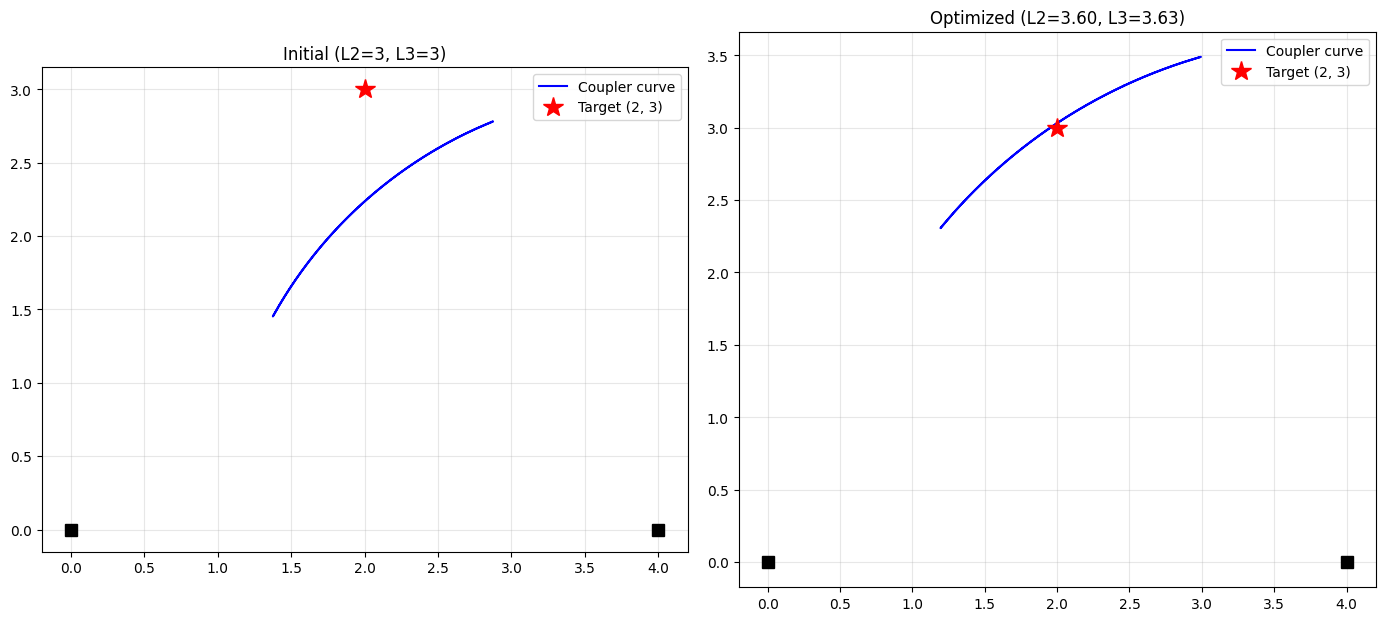

In [9]:
# Compare initial vs optimized coupler curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, p, title in [
    (ax1, {"L2": 3.0, "L3": 3.0}, "Initial (L2=3, L3=3)"),
    (ax2, result.params, f"Optimized (L2={result.params['L2']:.2f}, L3={result.params['L3']:.2f})"),
]:
    traj = compute_trajectory_numeric(linkage, p, theta_values)
    C = traj["C"]
    valid = ~np.isnan(C[:, 0])
    ax.plot(C[valid, 0], C[valid, 1], 'b-', linewidth=1.5, label='Coupler curve')
    ax.plot(2, 3, 'r*', markersize=15, label='Target (2, 3)')
    ax.plot(0, 0, 'ks', markersize=8)
    ax.plot(4, 0, 'ks', markersize=8)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Symbolic Derivatives

Compute velocity expressions by differentiating trajectory w.r.t. theta.

In [10]:
# Compute velocity symbolically using the numeric four-bar (no symbolic params = fast)
x_C_num_expr, y_C_num_expr = traj_num["C"]

vx_C_num = sp.diff(x_C_num_expr, theta)
vy_C_num = sp.diff(y_C_num_expr, theta)

print("Coupler velocity (numeric params, symbolic theta):")
print(f"vx_C = {sp.simplify(vx_C_num)}")
print(f"\nvy_C = {sp.simplify(vy_C_num)}")

Coupler velocity (numeric params, symbolic theta):
vx_C = (-0.5*(17.0 - 8.0*cos(theta))**(5/2)*sqrt(8.0*cos(theta) + 19.0)*sin(theta) + 0.5*(17.0 - 8.0*cos(theta))**2*(8.0*cos(theta) + 19.0)*cos(theta) - 2.0*(17.0 - 8.0*cos(theta))**2*sin(theta)**2 - 2.0*(17.0 - 8.0*cos(theta))*(8.0*cos(theta) + 19.0)*sin(theta)**2)/((17.0 - 8.0*cos(theta))**(5/2)*sqrt(8.0*cos(theta) + 19.0))

vy_C = (64.0*sqrt(17.0 - 8.0*cos(theta))*sqrt(8.0*cos(theta) + 19.0)*cos(theta)**2 - 136.0*sqrt(17.0 - 8.0*cos(theta))*sqrt(8.0*cos(theta) + 19.0)*cos(theta) + 512.0*sin(theta)*cos(theta)**2 + 2024.0*sin(theta) - 512.0*sin(2*theta))/(sqrt(17.0 - 8.0*cos(theta))*sqrt(8.0*cos(theta) + 19.0)*(128.0*cos(theta) - 272.0))


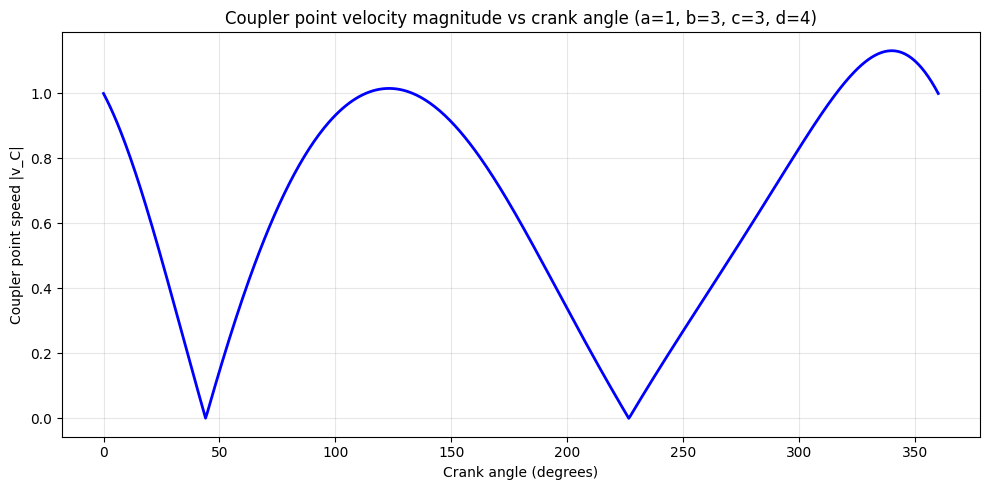

In [11]:
# Numeric velocity plot using lambdify
vx_func = sp.lambdify(theta, vx_C_num, modules='numpy')
vy_func = sp.lambdify(theta, vy_C_num, modules='numpy')

vx_vals = vx_func(theta_values)
vy_vals = vy_func(theta_values)
speed_vals = np.sqrt(np.array(vx_vals)**2 + np.array(vy_vals)**2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.degrees(theta_values), speed_vals, 'b-', linewidth=2)
ax.set_xlabel('Crank angle (degrees)')
ax.set_ylabel('Coupler point speed |v_C|')
ax.set_title('Coupler point velocity magnitude vs crank angle (a=1, b=3, c=3, d=4)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

Pylinkage's symbolic module provides capabilities not found in typical mechanism packages:

| Feature | Numeric (standard) | Symbolic (pylinkage) |
|---|---|---|
| Trajectory | Sampled points | Closed-form expressions |
| Coupler curve | Point cloud | Algebraic equation f(x,y)=0 |
| Optimization | Finite-difference gradients | Analytical gradients |
| Velocity/Acceleration | Numerical differentiation | Exact derivatives |
| Parameter studies | Re-simulate for each value | Substitute into formula |

**When to use symbolic analysis:**
- Understanding how parameters affect the coupler curve shape
- Exact derivatives for gradient-based optimization
- Generating code for embedded controllers (lambdify)
- Mathematical research on linkage properties